In [1]:
source("/mnt/users/rachelsavage/paper_minimorf/code/figure_code/Figure_Code_Presets.r")


In [2]:
atac.edge.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/atac.edge.df.rds")
atac.node.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/atac.node.df.rds")
rna.edge.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.edge.df.rds")
rna.node.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.node.df.rds")

In [29]:
colnames(rna.edge.df)

[1] "from"                    "to"                     
 [3] "x_from"                  "y_from"                 
 [5] ".ggraph.orig_index_from" "circular_from"          
 [7] ".ggraph.index_from"      "iteration_from"         
 [9] "cluster_from"            "degree_from"            
[11] "comp_id_from"            "cluster_size_from"      
[13] "deg_cat_from"            "label_from"             
[15] "x_to"                    "y_to"                   
[17] ".ggraph.orig_index_to"   "circular_to"            
[19] ".ggraph.index_to"        "iteration_to"           
[21] "cluster_to"              "degree_to"              
[23] "comp_id_to"              "cluster_size_to"        
[25] "deg_cat_to"              "label_to"

In [57]:
cols <- qualitative_hcl(10, palette = "Dark 3")
cols <- brewer.pal(10, "Paired")

atac.plt <- ggplot()+
geom_segment(data = atac.edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.1/.pt,
            color = "black")+
geom_point(data = atac.node.df, aes(x=x, y=y, fill = as.factor(iteration)),  shape = 21, stroke = 0.25/.pt,
           size = 2/.pt)+
#geom_text_repel(data = atac.node.df, aes(x=x, y=y, label = label))+
scale_fill_manual(values = cols)+
theme_void()+
coord_fixed()+
theme(    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 0.5/.pt
))


rna.plt <- ggplot()+
geom_segment(data = rna.edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = rna.node.df, aes(x=x, y=y, fill = as.factor(iteration)), shape = 21, stroke = 0.25/.pt,
           size = 2/.pt)+
#geom_text_repel(data = rna.node.df, aes(x=x, y=y, label = label))+
scale_fill_manual(values = cols)+
theme_void()+
coord_fixed()+
theme(    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 0.5/.pt
))


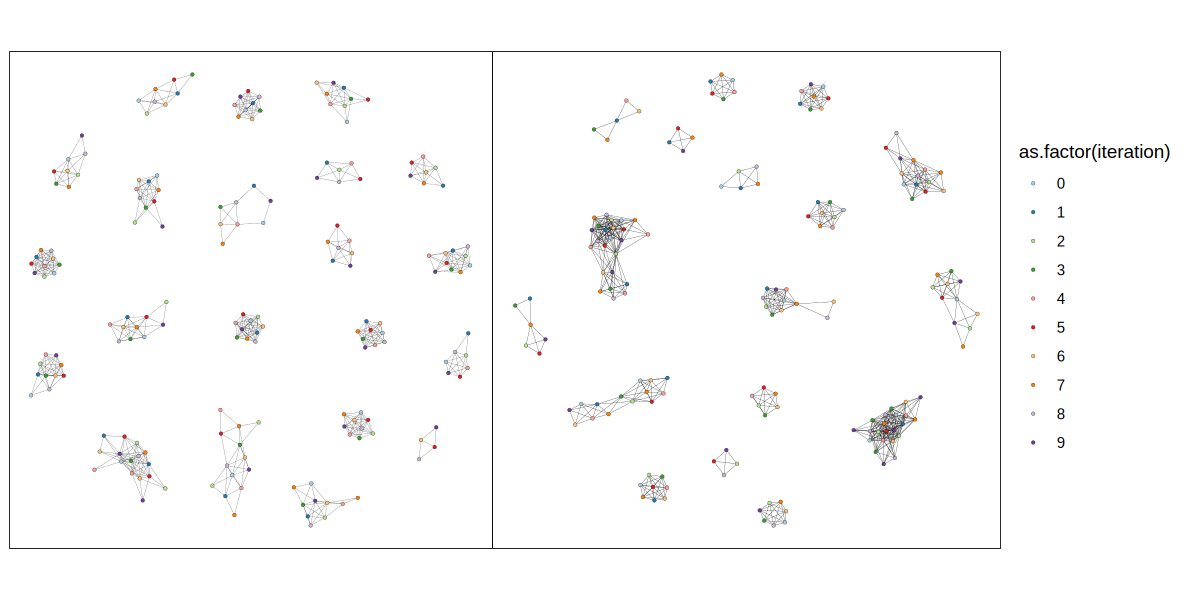

In [58]:
options(repr.plot.width = 10, repr.plot.height = 5)
final.plt <- atac.plt + rna.plt +   plot_layout(guides = "collect")
final.plt 

In [59]:
ggsave("/mnt/users/rachelsavage/paper_minimorf/paper_figures/fig2/rna.atac.metatopic.svg",
       final.plt, height = 2, width = 4, units = "in")